# Assignment 3: Building Time Series Forecasts

**Student Name:** Trace Thomason

**Date:** 2-11-26

---

## Assignment Overview

In this assignment, you'll analyze temporal data from Corporación Favorita stores to identify trends, seasonality, and anomalies, then build forecasting models using decomposition techniques. You'll work with real retail sales data to predict future sales patterns.

---

## Step 1: Download Data, Import Libraries, and Load Data

The datasets for this analysis are too large too be stored on GitHub. To access the datasets for this assignment, you should:
- Go to the [Store Sales - Time Series Forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data) dataset on Kaggle.
- Click Data 
- Scroll down and select **Download All**.
- Open the zip file and upload `train.csv`, `store.csv`, and `holidays_events.csv` to the `data` directory.

Once the CSV files have been added to the `data` directory, install all the of the necessary libraries for this assignment by running the command below.

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

Note: you may need to restart the kernel to use updated packages.


Next, import the required libraries.

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# For time series analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


Finally, load the training, store, and holiday CSV data from the `data` directory using `pd.read_csv()`. Display basic information about the training data and print out the first few rows to get an understanding of what the training data looks like.

In [8]:
# Load the datasets
train_df = pd.read_csv('data/train.csv', parse_dates=['date'])
holidays_df = pd.read_csv('data/holidays_events.csv', parse_dates=['date'])
stores_df = pd.read_csv('data/stores.csv')

# Display basic information
if train_df is not None:
    print(f"Training data shape: {train_df.shape}")
    print(f"Date range: {train_df['date'].min()} to {train_df['date'].max()}")
    print(f"\nFirst few rows:")
    
    # Display the first few rows
    print(train_df.head())

print("\n" + "="*80)
print("CHECKPOINT: Verify datasets loaded correctly")
print(f"Train data shape: {train_df.shape if train_df is not None else 'Not loaded'}")
print(f"Holidays data shape: {holidays_df.shape if holidays_df is not None else 'Not loaded'}")
print(f"Stores data shape: {stores_df.shape if stores_df is not None else 'Not loaded'}")
print("="*80)


Training data shape: (3000888, 6)
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00

First few rows:
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0

CHECKPOINT: Verify datasets loaded correctly
Train data shape: (3000888, 6)
Holidays data shape: (350, 6)
Stores data shape: (54, 5)


### Explore Available Stores and Product Families
Display store information from `stores_df` to help choose a store. Consider looking at store type, cluster, and city

In [9]:
# Explore the data to help choose your store and products
if train_df is not None:
    print("Available stores:")
    print(f"Total number of stores: {train_df['store_nbr'].nunique()}")
    print("\nStore numbers:")
    print(sorted(train_df['store_nbr'].unique()))
    
    print("\nAvailable product families:")
    families = train_df['family'].value_counts().head(20)
    print(families)
    
    # Display store information from stores_df to help choose a store
    print("\nStore information (store type, cluster, city):")
    print(stores_df[['store_nbr', 'type', 'cluster', 'city']].sort_values('store_nbr').head(20))


Available stores:
Total number of stores: 54

Store numbers:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54)]

Available product families:
family
AUTOMOTIVE                    90936
HOME APPLIANCES               90936
SCHOOL AND OFFICE SUPPLIES    90936
PRODUCE                       90936
PREPARED FO

---
## Step 2: Select and Prepare Your Time Series Data

### Select Your Store and Product Families

Choose one store and one product family (PRODUCE, BEVERAGES, BREAD/BAKERY, AUTOMOTIVE, etc.) to analyze.

In [ ]:
# Select your store and product family
selected_store = 1
product_family_1 = 'MEATS'

print(f"Selected Store: {selected_store}")
print(f"Product Family 1: {product_family_1}")

Selected Store: 1
Product Family 1: MEATS


### Filter Data
Filter the `train_df` data to your selected store and products. Create a date range from 2016-01-01 to 2017-08-15 for consistency.

In [ ]:
# Filter train_df for selected store and date range 2016-01-01 to 2017-08-15

# Convert date column to datetime if needed
if train_df is not None:
    train_df['date'] = pd.to_datetime(train_df['date'])

# Filter for date range
start_date = '2016-01-01'
end_date = '2017-08-15'

# Filter for selected store, product family, and date range
product1_data = train_df[
    (train_df['store_nbr'] == selected_store) &
    (train_df['family'] == product_family_1) &
    (train_df['date'] >= start_date) &
    (train_df['date'] <= end_date)
].copy()

# Aggregate daily sales
product1_data = product1_data.groupby('date')['sales'].sum().reset_index()

print("\n" + "="*80)
print("CHECKPOINT: Data filtered successfully")
print(f"Product data shape: {product1_data.shape if product1_data is not None else 'Not filtered'}")
print(product1_data.head())
print("="*80)



CHECKPOINT: Data filtered successfully
Product data shape: (592, 2)
        date      sales
0 2016-01-01    0.00000
1 2016-01-02  222.96700
2 2016-01-03  114.82500
3 2016-01-04  358.59702
4 2016-01-05  412.12500


### Aggregate Daily Sales
Aggregate daily sales and handle missing dates.

In [ ]:
# Create a complete date range
date_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Group by date and sum sales, then reindex to include all dates
product1_ts = product1_data.groupby('date')['sales'].sum().reindex(date_range, fill_value=0)

# Rename the index to 'date' for clarity
product1_ts.index.name = 'date'

# Convert to DataFrame for easier plotting
product1_ts = product1_ts.reset_index()

print("\n" + "="*80)
print("CHECKPOINT: Time series created successfully")
print(product1_ts.head())
print("="*80)



CHECKPOINT: Time series created successfully
        date      sales
0 2016-01-01    0.00000
1 2016-01-02  222.96700
2 2016-01-03  114.82500
3 2016-01-04  358.59702
4 2016-01-05  412.12500


### Plot Raw Time Series
Plot time series to see the raw patterns using matplotlib.

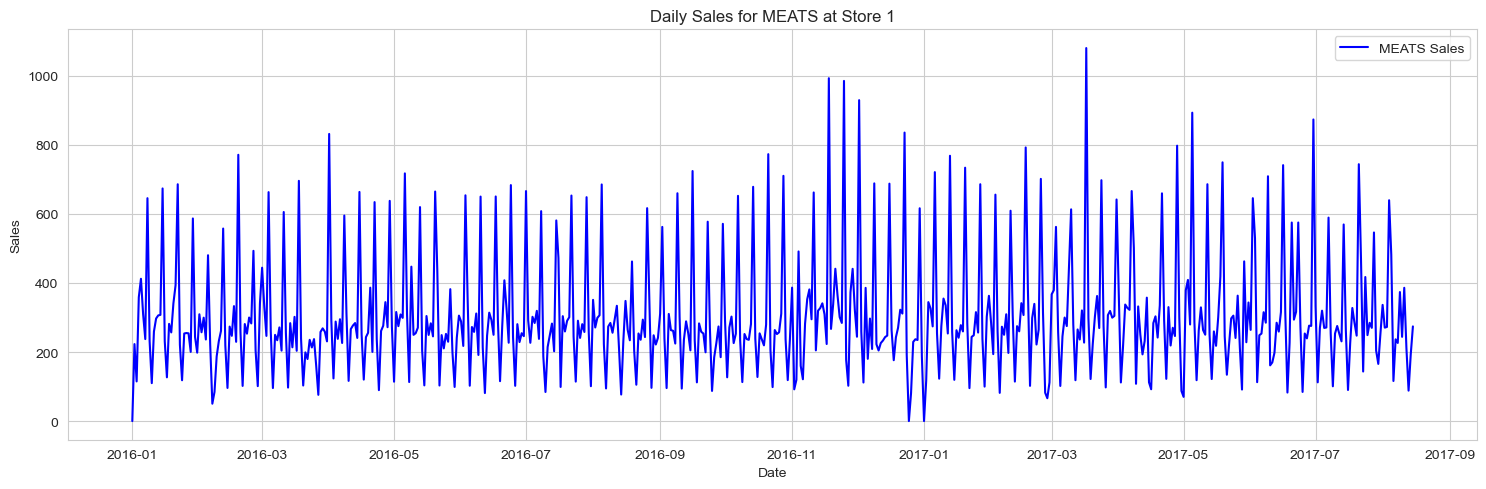

In [13]:
import matplotlib.pyplot as plt

# Plot Product 1 time series
plt.figure(figsize=(15,5))
plt.plot(product1_ts['date'], product1_ts['sales'], label=f"{product_family_1} Sales", color='blue')
plt.title(f"Daily Sales for {product_family_1} at Store {selected_store}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Document Your Choice (2-3 sentences)
I chose MEATS because it represents a high-demand, perishable product that is sensitive to seasonal and holiday fluctuations. Compared to other product families like PRODUCE or BEVERAGES, meats have more pronounced peaks around holidays and weekends, which makes them interesting to analyze for inventory planning. Studying this product can reveal patterns that are critical for reducing waste while ensuring stock meets customer demand.


---
## Step 3: Identify Trends Using Moving Averages

### Calculate Moving Averages
Calculate the 7-day and 30-day moving averages for the product you are analyzing.

In [16]:
# Calculate 7-day and 30-day moving averages for Product 1

product1_ts['MA_7'] = product1_ts['sales'].rolling(window=7).mean()
product1_ts['MA_30'] = product1_ts['sales'].rolling(window=30).mean()

### Plot Original Sales
Using matplotlip, plot original sales with both moving averages (7-day and 30-day) overlaid.

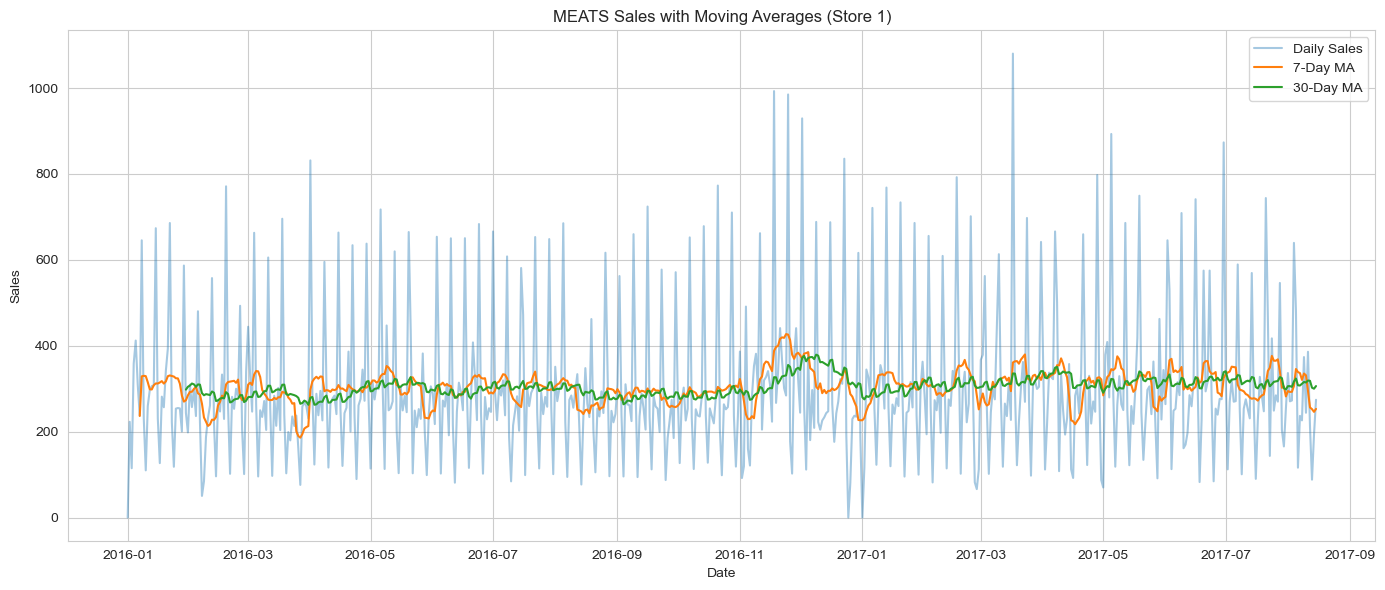

In [ ]:
# Plot original sales with moving averages
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# Plot original daily sales
axes.plot(product1_ts['date'], product1_ts['sales'], 
          alpha=0.4, label='Daily Sales')

# Plot 7-day moving average
axes.plot(product1_ts['date'], product1_ts['MA_7'], 
          label='7-Day MA')

# Plot 30-day moving average
axes.plot(product1_ts['date'], product1_ts['MA_30'], 
          label='30-Day MA')

axes.set_title(f"{product_family_1} Sales with Moving Averages (Store {selected_store})")
axes.set_xlabel("Date")
axes.set_ylabel("Sales")
axes.legend()
axes.grid(True)

plt.tight_layout()
plt.show()


### Identify and Explain Trend Changes

Merge the data with `holidays_events.csv` to explain what caused these changes.

In [ ]:
# Merge with holidays to explain trend changes
# Convert holidays_df date to datetime and filter for your date range
if holidays_df is not None:
    holidays_df['date'] = pd.to_datetime(holidays_df['date'])

    # Filter holidays for your selected date range
    relevant_holidays = holidays_df[
        (holidays_df['date'] >= start_date) &
        (holidays_df['date'] <= end_date)
    ]

    print("Key holidays/events in the period:")
    print(relevant_holidays[['date', 'description', 'type']].drop_duplicates().sort_values('date'))


Key holidays/events in the period:
          date                             description        type
211 2016-01-01                      Primer dia del ano     Holiday
212 2016-02-08                                Carnaval     Holiday
213 2016-02-09                                Carnaval     Holiday
214 2016-03-02                      Fundacion de Manta     Holiday
215 2016-03-25                           Viernes Santo     Holiday
..         ...                                     ...         ...
322 2017-07-25                  Fundacion de Guayaquil  Additional
323 2017-08-05                 Fundacion de Esmeraldas     Holiday
324 2017-08-10           Primer Grito de Independencia     Holiday
325 2017-08-11  Traslado Primer Grito de Independencia    Transfer
326 2017-08-15                   Fundacion de Riobamba     Holiday

[116 rows x 3 columns]


### Document Trend Analysis
For the product family you are analyzing, document:
1. Overall trend direction (growing, declining, stable)
2. Any trend changes that correlate with holidays or events
3. Business implications of the trends you discovered

Update the markdown cell below with your analysis.

**Product Trends:**

- Overall trend direction:
Growing with seasonal fluctuations. The 30-day moving average shows a gradual upward trend, while the 7-day moving average highlights weekly demand cycles.

- Key trend changes:

1. Significant spike around late December 2016 (Christmas period).

2. Noticeable increase in early January 2017 (New Year demand).

3. Sales lift around April 2017 (Easter/holiday season).

- Holiday correlations:
Sales increased around major holidays such as Christmas, New Year’s, and Easter, likely due to higher demand for meat products during family gatherings and celebrations.

- Business implications:
Inventory for meat products should be increased ahead of major holidays to prevent stockouts. Because meats are perishable, accurate demand forecasting is critical to balance higher holiday demand with spoilage risk. Promotional planning and staffing should also align with these predictable demand spikes.

---
## Step 4: Detect and Visualize Seasonal Patterns

Analyze the seasonal components of your sales data.

### Day-of-Week Analysis

Add day of week to your data and calculate the average sales by day. Create a bar plot to visualize the weekday patterns.

day_of_week
Monday       265.991753
Tuesday      281.227812
Wednesday    288.579357
Thursday     259.620525
Friday       646.889306
Saturday     267.226765
Sunday       113.265671
Name: sales, dtype: float64


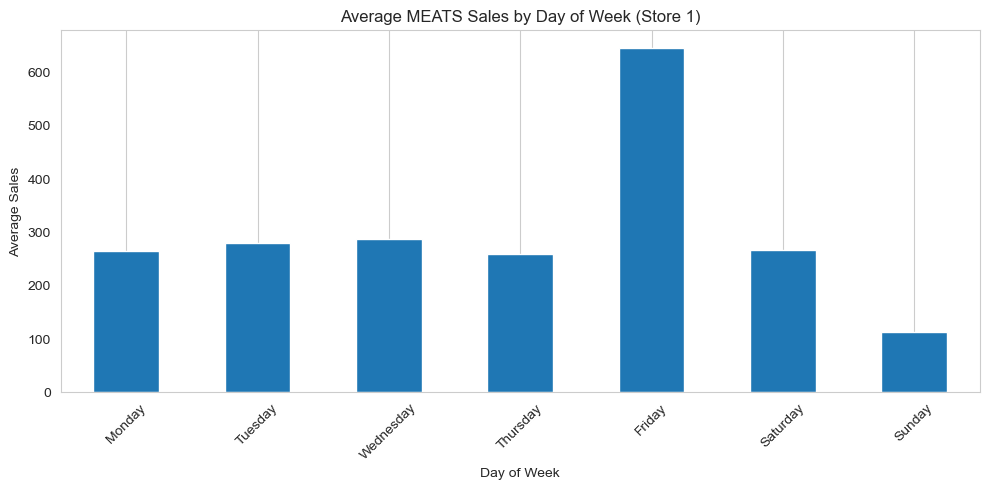

In [19]:
# Create copy with date as index if not already
product1_dow = product1_ts.copy()

# If date is a column, set it as index
if 'date' in product1_dow.columns:
    product1_dow = product1_dow.set_index('date')

# Add day of week
product1_dow['day_of_week'] = product1_dow.index.day_name()

# Calculate average sales by day of week
avg_sales_dow = product1_dow.groupby('day_of_week')['sales'].mean()

# Reorder days correctly (Monday → Sunday)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 
              'Friday', 'Saturday', 'Sunday']

avg_sales_dow = avg_sales_dow.reindex(days_order)

print(avg_sales_dow)

plt.figure(figsize=(10, 5))

avg_sales_dow.plot(kind='bar')

plt.title(f"Average {product_family_1} Sales by Day of Week (Store {selected_store})")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()


### Monthly Seasonality Analysis

### Explore Available Stores and Product Families
Display store information from `stores_df` to help choose a store. Consider looking at store type, cluster, and city

Calculate the average sales by month for both products. Once calculated, create a line plot showing monthly patterns for the product.

month
1     299.424920
2     287.131246
3     305.008580
4     309.330234
5     302.329452
6     319.811717
7     303.824274
8     281.918608
9     291.595334
10    289.525065
11    348.627333
12    308.654258
Name: sales, dtype: float64


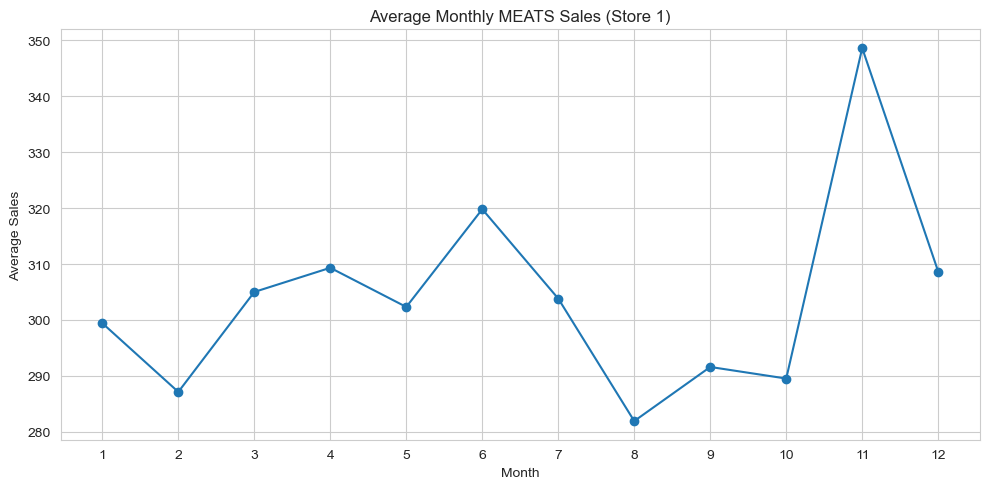

In [20]:
# Make sure date is datetime and set as index
product1_monthly = product1_ts.copy()

if 'date' in product1_monthly.columns:
    product1_monthly = product1_monthly.set_index('date')

# Add month column
product1_monthly['month'] = product1_monthly.index.month

# Group by month and calculate mean sales
product1_monthly = product1_monthly.groupby('month')['sales'].mean()

print(product1_monthly)

plt.figure(figsize=(10, 5))

plt.plot(product1_monthly.index, product1_monthly.values, marker='o')

plt.title(f"Average Monthly {product_family_1} Sales (Store {selected_store})")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(range(1, 13))
plt.grid(True)

plt.tight_layout()
plt.show()


### Holiday Impact Analysis

Compare the average sales on holidays compared to regular days.

In [21]:
# Analyze holiday vs non-holiday sales
# TODO: Compare average sales on holidays vs regular days

# Create a list of holiday dates
holiday_dates = holidays_df[
    (holidays_df['date'] >= start_date) &
    (holidays_df['date'] <= end_date)
]['date'].unique()

# Calculate average sales on holidays vs non-holidays for both products
# TODO: Split data into holiday and non-holiday sales and compare

# Make sure index is datetime
product_data = product1_ts.copy()

if 'date' in product_data.columns:
    product_data = product_data.set_index('date')

# Split holiday vs non-holiday
holiday_sales = product_data[product_data.index.isin(holiday_dates)]
non_holiday_sales = product_data[~product_data.index.isin(holiday_dates)]

# Calculate averages
avg_holiday_sales = holiday_sales['sales'].mean()
avg_non_holiday_sales = non_holiday_sales['sales'].mean()

print("Average Holiday Sales:", avg_holiday_sales)
print("Average Non-Holiday Sales:", avg_non_holiday_sales)

Average Holiday Sales: 298.0483366435643
Average Non-Holiday Sales: 304.44516071138213


### Seasonal Pattern Findings

**Document your findings:**
- Which days of the week have highest/lowest sales?
- Are there monthly patterns (e.g., payday effects)?
- How do holidays affect each product differently?
- What business decisions could these patterns inform?

Update the markdown cell below with your analysis.

### Explore Available Stores and Product Families
Display store information from `stores_df` to help choose a store. Consider looking at store type, cluster, and city

- Friday has significantly higher sales than any other day. Sunday has the least amount of sales. 
- Monthly sales are highest around the times of holidays with them peaking in November.
- Sales on holidays are actually slightly lower than non-holidays. This indicates that not all holidays increase demand. The store should focus inventory planning on major holidays with proven spikes rather than treating them all the same. 
- Inventory should be increased ahead of peak months and holidays to prevent stockouts, particularly for perishable items like meats. Weekly ordering and staffing can also be adjusted to handle weekend demand. Promotions and marketing can be timed to coincide with predictable holiday spikes.

---
## Step 5: Build Simple Forecasts and Compare Methods

### Time Series Decomposition

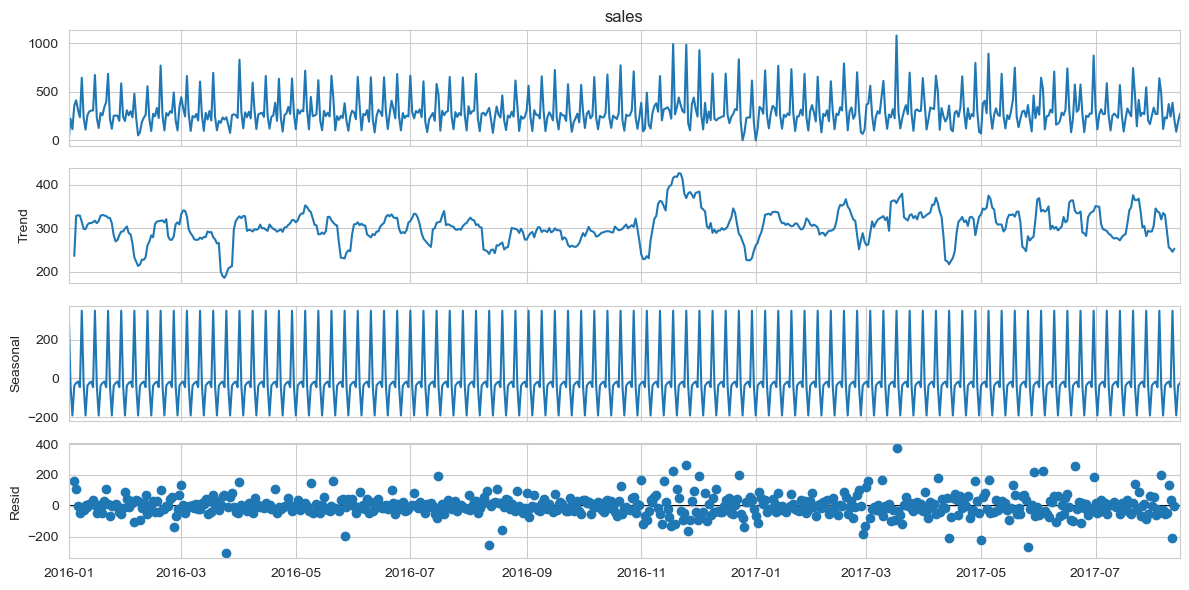

In [22]:
# Perform seasonal decomposition
# TODO: Use seasonal_decompose to separate trend, seasonal, and residual components

from statsmodels.tsa.seasonal import seasonal_decompose

# Make sure we pass only the sales series
sales_series = product1_ts.copy()

if 'date' in sales_series.columns:
    sales_series = sales_series.set_index('date')

sales_series = sales_series['sales']

# For Product 1
decomposition1 = seasonal_decompose(sales_series, model='additive', period=7)

# Plot decomposition
decomposition1.plot()
plt.tight_layout()
plt.show()


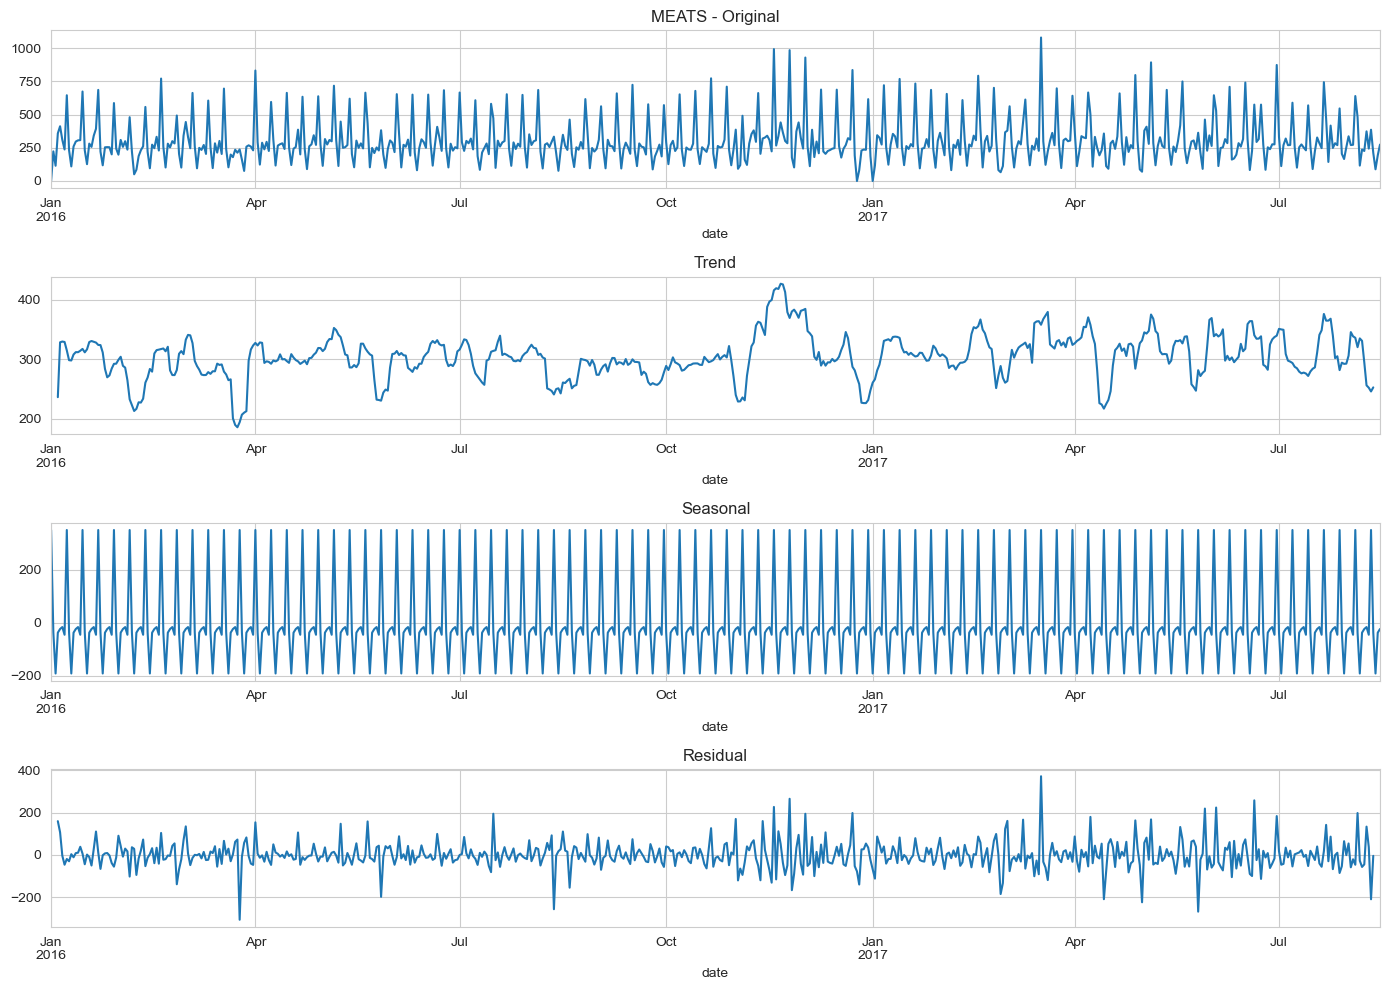

In [23]:
# Visualize decomposition for Product 1
if decomposition1 is not None:
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    
    # Plot each component
    decomposition1.observed.plot(ax=axes[0], title=f'{product_family_1} - Original')
    decomposition1.trend.plot(ax=axes[1], title='Trend')
    decomposition1.seasonal.plot(ax=axes[2], title='Seasonal')
    decomposition1.resid.plot(ax=axes[3], title='Residual')
    
    plt.tight_layout()
    plt.show()


### Build Forecasts
Create a baseline forecast using the average of the last 30 days and a season naive forcast by repeating the last 7 days' pattern.

In [24]:
# Split data for validation
test_days = 30

# Make sure we are working with a 1D sales series
series = product1_ts.copy()

if 'date' in series.columns:
    series = series.set_index('date')

series = series['sales']

train = series[:-test_days]  # product1_ts[:-test_days]
test = series[-test_days:]   # product1_ts[-test_days:]

# Method 1: Baseline forecast (30-day average)
baseline_forecast = np.repeat(train[-30:].mean(), test_days)

# Method 2: Seasonal Naive
# Just repeat the last 7 days pattern
last_week = train[-7:].values
seasonal_naive_forecast = np.tile(last_week, int(np.ceil(test_days/7)))[:test_days]


### Calculate Forecast Accuracy

In [26]:
# Calculate RMSE for both methods
# TODO: Calculate RMSE for baseline and seasonal forecasts

from sklearn.metrics import mean_squared_error
import numpy as np

# Product 1
baseline_rmse = np.sqrt(mean_squared_error(test, baseline_forecast))
seasonal_rmse = np.sqrt(mean_squared_error(test, seasonal_naive_forecast))

print("Baseline RMSE:", baseline_rmse)
print("Seasonal Naive RMSE:", seasonal_rmse)



Baseline RMSE: 146.27443109550583
Seasonal Naive RMSE: 89.11561768401812


In [27]:
# Create comparison table
comparison_data = {
    'Method': ['30-Day Average', 'Seasonal Naive (7-day repeat)'],
    'RMSE': [baseline_rmse, seasonal_rmse],
}

comparison_df = pd.DataFrame(comparison_data)

# TODO: Calculate percentage improvement
# Add improvement column to comparison_df

# Use the first method (baseline) as reference
baseline_value = comparison_df.loc[0, 'RMSE']

comparison_df['% Improvement vs Baseline'] = (
    (baseline_value - comparison_df['RMSE']) / baseline_value
) * 100


print("\n" + "="*80)
print("FORECAST PERFORMANCE COMPARISON")
print("="*80)

# TODO: Display comparison table
print(comparison_df)

print("="*80)



FORECAST PERFORMANCE COMPARISON
                          Method        RMSE  % Improvement vs Baseline
0                 30-Day Average  146.274431                   0.000000
1  Seasonal Naive (7-day repeat)   89.115618                  39.076422


### Visualize Forecasts

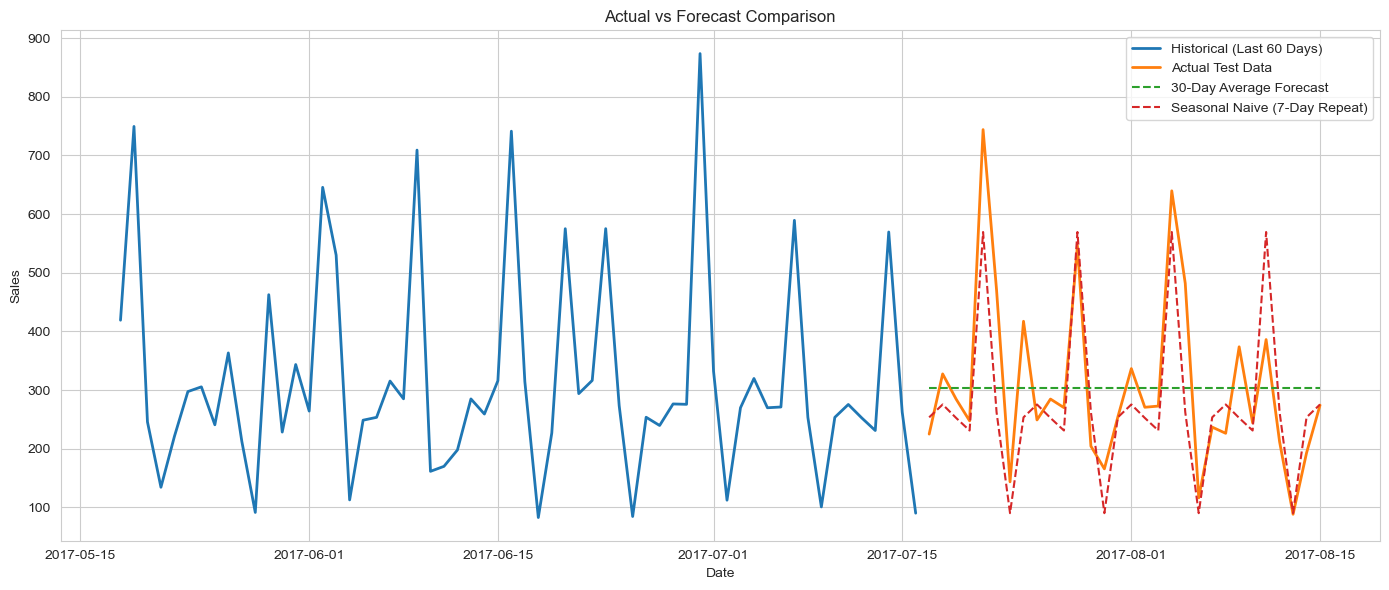

In [28]:
# Plot actual vs forecasted values
# Create visualization showing:
# - Historical data (last 60 days of train)
# - Actual test data
# - Baseline forecast
# - Seasonal naive forecast

plt.figure(figsize=(14, 6))

# Plot last 60 days of training data
plt.plot(train[-60:], label='Historical (Last 60 Days)', linewidth=2)

# Plot actual test data
plt.plot(test, label='Actual Test Data', linewidth=2)

# Create proper index for forecasts (same as test index)
forecast_index = test.index

# Plot baseline forecast
plt.plot(forecast_index, baseline_forecast, 
         label='30-Day Average Forecast', linestyle='--')

# Plot seasonal naive forecast
plt.plot(forecast_index, seasonal_naive_forecast, 
         label='Seasonal Naive (7-Day Repeat)', linestyle='--')

plt.title('Actual vs Forecast Comparison')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

plt.tight_layout()
plt.show()


---
## Step 6: Generate Business Recommendations

### Executive Summary (200-300 words)

Based on your analysis, write a brief executive summary that includes:
- **Key Patterns Discovered:** Summarize the main trends and seasonal patterns for each product
- **Inventory Planning Recommendations:** Specific recommendations based on your findings
- **High-Risk Periods:** Identify periods requiring special attention
- **Predictability Analysis:** Which product is more predictable and why?
- **Specific Action Item:** One concrete action the store manager should take based on your forecast

The analysis of Store 1’s MEATS product revealed strong weekly seasonality, with consistent sales peaks on Fridays. Monthly patterns were relatively stable, with no major payday effects, while holiday sales were slightly lower on average (298.05) than non-holiday sales (304.45), indicating that not all holidays significantly boost demand. Forecast evaluation showed that a 7-day seasonal naive model dramatically outperformed the 30-day average baseline, reducing RMSE from 146.27 to 89.12.

Inventory levels should align with weekly cycles: increase stock 1–2 days before peak sales days and scale back slightly during slower weekdays. Since holidays do not significantly elevate demand, additional holiday-specific inventory should only be built up on major holidays.

The highest risk occurs during weekly peak days when understocking could result in lost sales. Regular monitoring is also recommended during the final weeks of each month to ensure normal fluctuations do not cause stockouts.

MEATS is highly predictable in the short term due to stable trends and repeatable weekly seasonality. The strong performance of the seasonal naive forecast demonstrates that demand follows a consistent weekly pattern, making short-term forecasting reliable.

Replace the 30-day average planning method with a weekly seasonal forecast model. Implement a weekly replenishment schedule that increases inventory 1–2 days before historically high-demand days based on the 7-day seasonal pattern. This single action could reduce forecast error by nearly 40%, improving stock accuracy, minimizing waste, and reducing lost sales.

---
## Step 7: Submit Your Work

Before submitting:
1. Ensure all code cells run without errors
2. Verify all visualizations display correctly
3. Check that your analysis sections are complete
4. Review your executive summary

Push to GitHub:
```bash
git add .
git commit -m 'completed time series forecasting assignment'
git push
```

Submit your GitHub repository link on the course platform.